# Bankruptcy Prevention — Classification Project

**Business Objective:** Model the probability that a business goes bankrupt based on 6 qualitative risk/flexibility features, using 250 companies' data.

**Target variable:** `class` — `bankruptcy` / `non-bankruptcy`

**Features (all take values 0 / 0.5 / 1):**
| Feature | Meaning |
|---|---|
| industrial_risk | 0=low, 0.5=medium, 1=high risk |
| management_risk | 0=low, 0.5=medium, 1=high risk |
| financial_flexibility | 0=low, 0.5=medium, 1=high flexibility |
| credibility | 0=low, 0.5=medium, 1=high credibility |
| competitiveness | 0=low, 0.5=medium, 1=high competitiveness |
| operating_risk | 0=low, 0.5=medium, 1=high risk |


## 1. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110


### 2. Load Data

In [5]:
import pandas as pd

df = pd.read_csv('bankruptcy_clean.csv')

feature_cols = ['industrial_risk', 'management_risk', 'financial_flexibility',
                'credibility', 'competitiveness', 'operating_risk']

df['target'] = df['class'].map({'bankruptcy': 1, 'non-bankruptcy': 0})
df.head()


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class,target
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy,1
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy,1
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy,1
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy,1
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy,1


## 3. Exploratory Data Analysis

In [7]:
print(df.shape)
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True))




(250, 8)
class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64
class
non-bankruptcy    0.572
bankruptcy        0.428
Name: proportion, dtype: float64


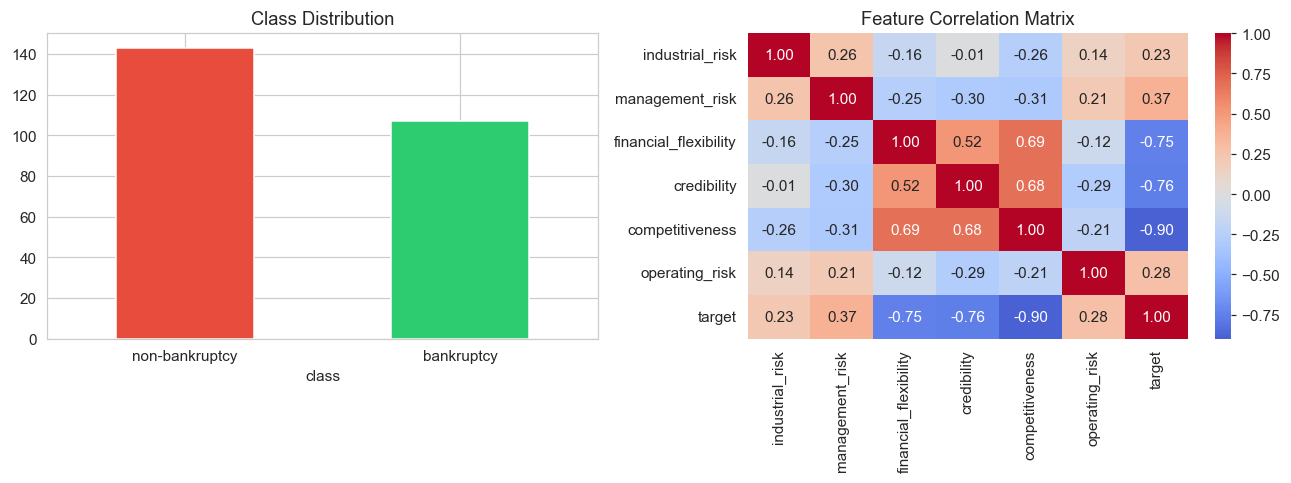

management_risk          0.370838
operating_risk           0.279786
industrial_risk          0.227823
financial_flexibility   -0.751020
credibility             -0.755909
competitiveness         -0.899452
Name: target, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution')
axes[0].tick_params(axis='x', rotation=0)

corr = df[feature_cols + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

corr['target'].drop('target').sort_values(ascending=False)


**Observation:** `competitiveness`, `credibility`, and `financial_flexibility` are strongly **negatively** correlated with bankruptcy (i.e. higher these values → lower bankruptcy risk), while `management_risk`, `industrial_risk`, `operating_risk` are positively correlated (higher risk → more likely bankruptcy). This matches business intuition.

### Count Plots

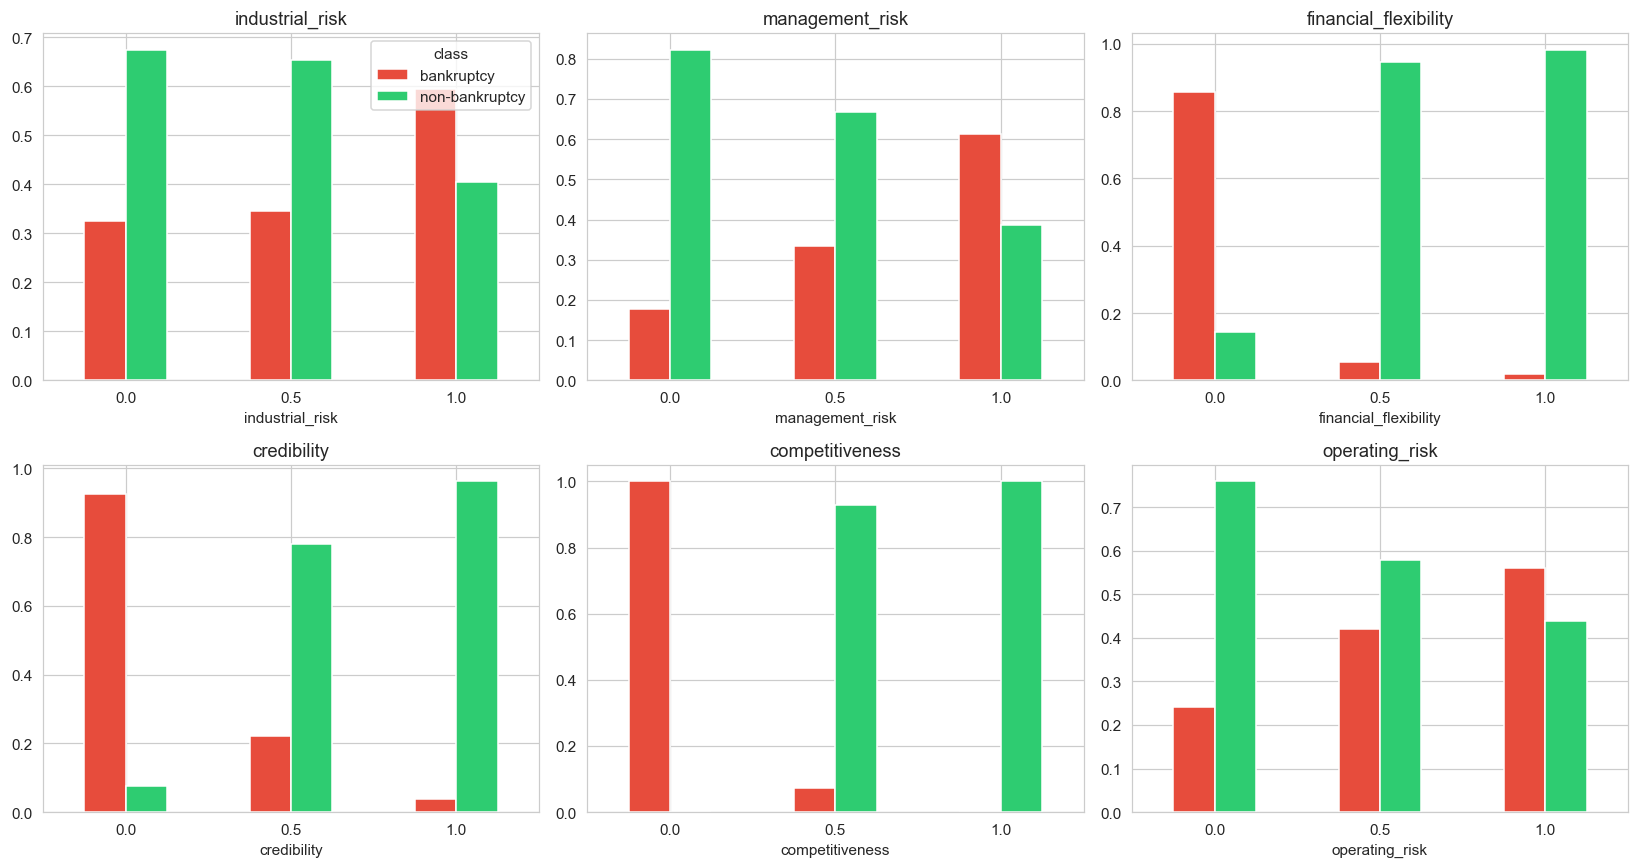

In [11]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    ct = pd.crosstab(df[col], df['class'], normalize='index')
    ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], legend=(i == 0))
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 3.1 Pairplot & Boxplots (deeper visual exploration)

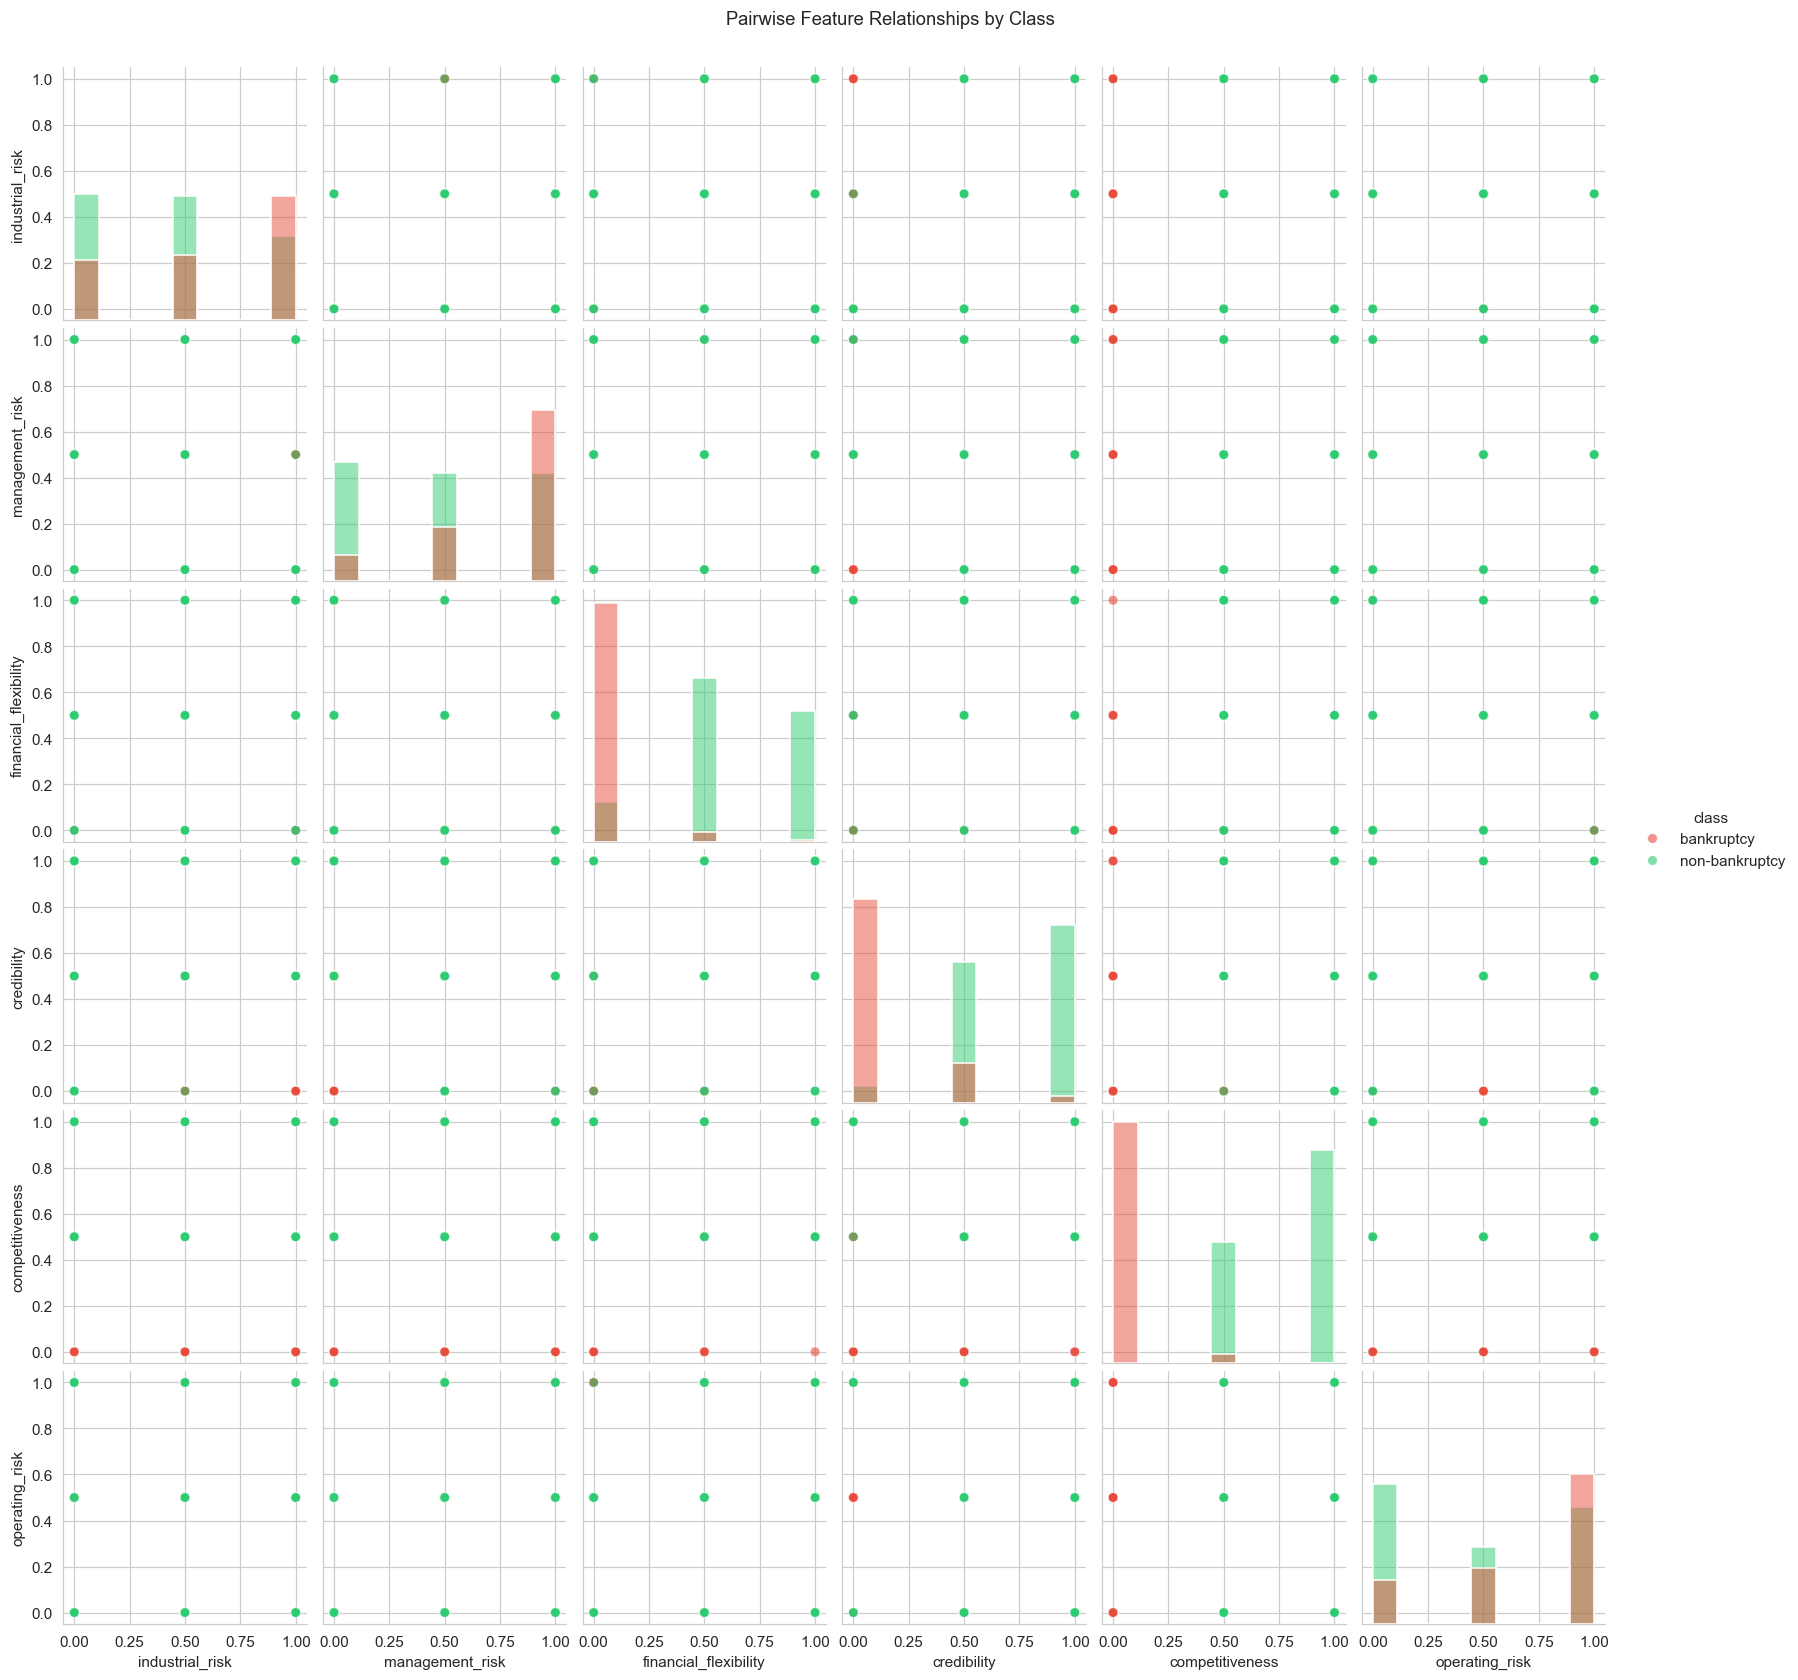

In [13]:

# Pairplot to see how features jointly separate the two classes
pp = sns.pairplot(df[feature_cols + ['class']], hue='class',
                   palette={'bankruptcy': '#e74c3c', 'non-bankruptcy': '#2ecc71'},
                   diag_kind='hist', plot_kws={'alpha': 0.6, 's': 40})
pp.fig.suptitle('Pairwise Feature Relationships by Class', y=1.02)
plt.show()


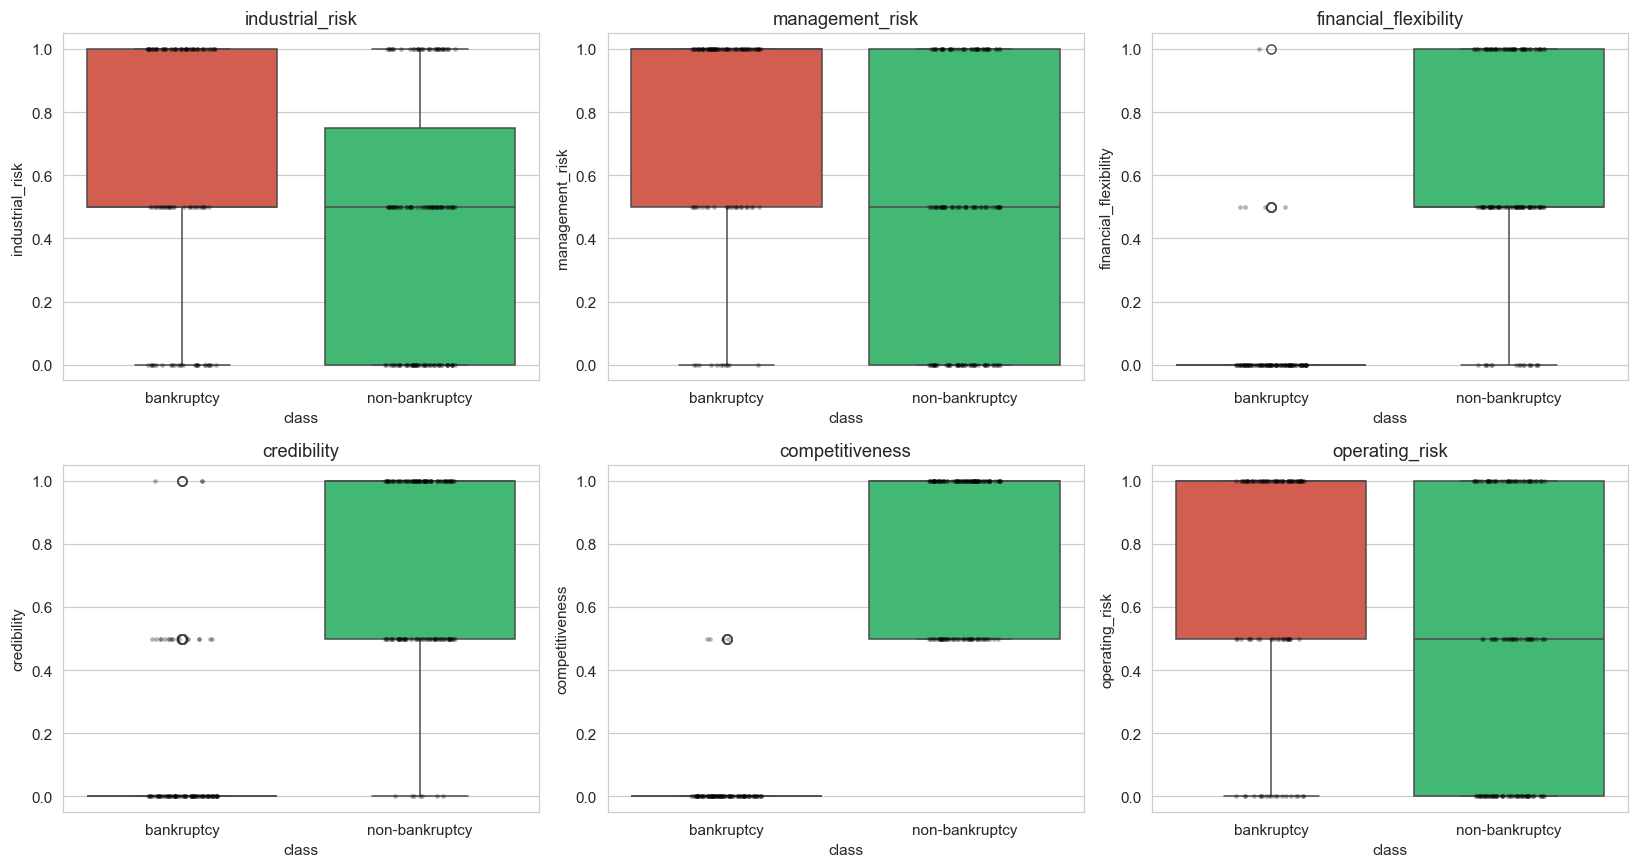

In [14]:
# Boxplots - distribution of each feature split by class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df, x='class', y=col, hue='class',
                palette={'bankruptcy': '#e74c3c', 'non-bankruptcy': '#2ecc71'},legend=False,
        ax=ax)
    sns.stripplot(data=df, x='class', y=col, ax=ax, color='black', alpha=0.3, size=3, jitter=0.15)
    ax.set_title(col)
plt.tight_layout()
plt.show()


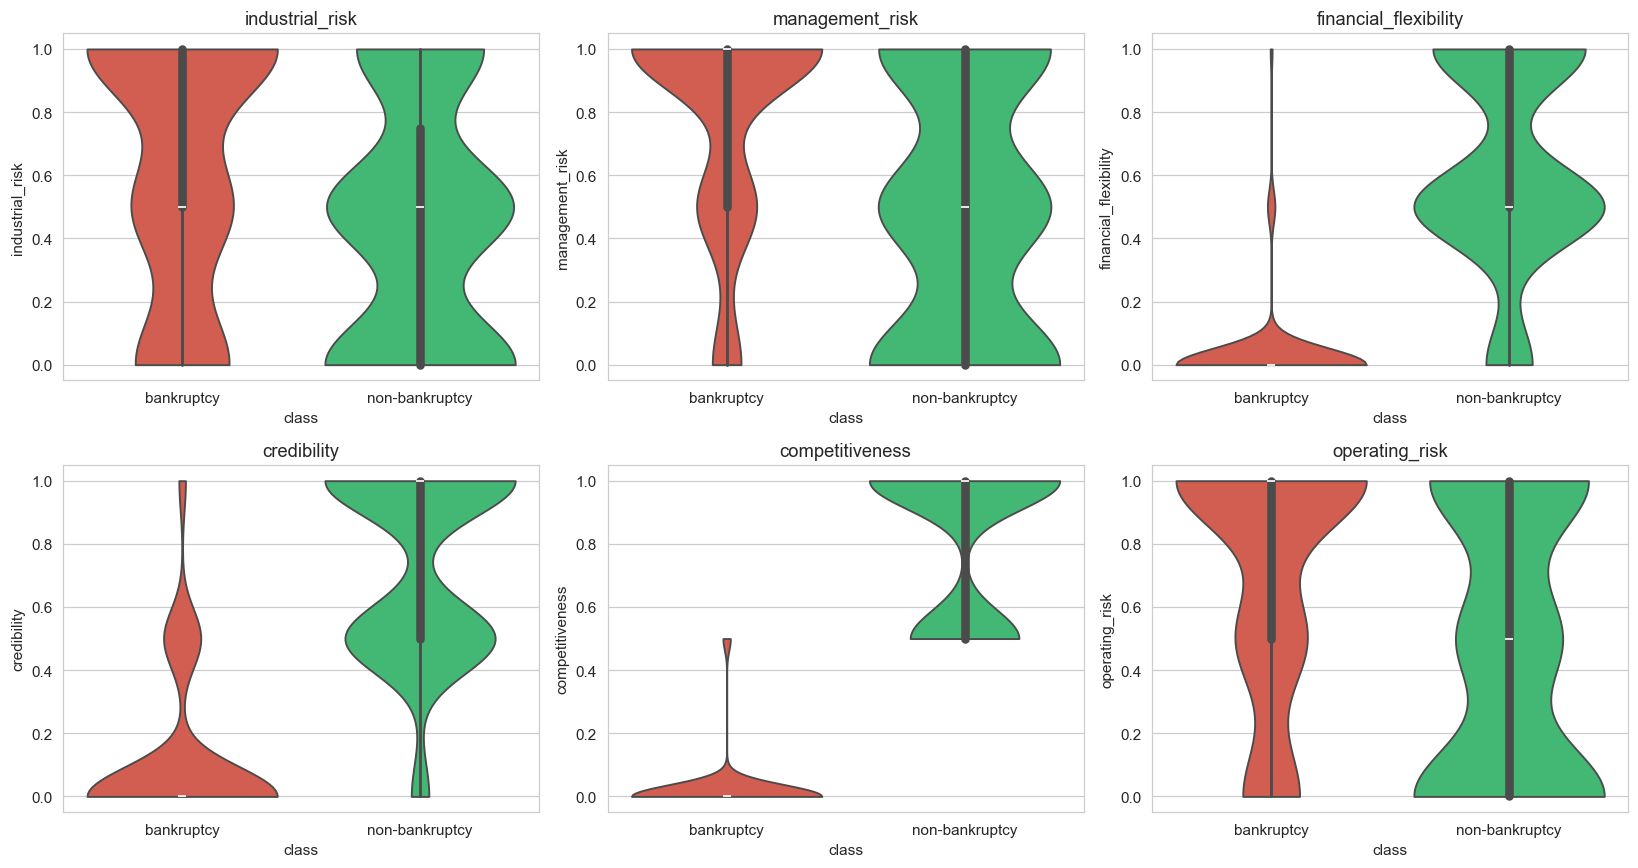

In [15]:
# Violin plots - shows density shape, useful since features are only 0/0.5/1
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    sns.violinplot(data=df, x='class', y=col, hue='class',
                    palette={'bankruptcy': '#e74c3c', 'non-bankruptcy': '#2ecc71'}, legend=False,
        cut=0,
        ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

The 6 raw features naturally split into two groups:
- **Risk indicators** (higher = worse): `industrial_risk`, `management_risk`, `operating_risk`
- **Strength indicators** (higher = better): `financial_flexibility`, `credibility`, `competitiveness`

We engineer new features that aggregate/combine these signals, which can help simpler models and also make the drivers of bankruptcy easier to communicate to business stakeholders:

1. **`avg_risk_score`** — mean of the 3 risk features
2. **`avg_strength_score`** — mean of the 3 strength features
3. **`risk_strength_gap`** — `avg_strength_score - avg_risk_score` (a single "health" score; higher = safer)
4. **`high_risk_count`** — how many of the 3 risk features are at the "high" (=1) level
5. **`low_strength_count`** — how many of the 3 strength features are at the "low" (=0) level


In [17]:
# Risk and strength feature groups
risk_cols = ['industrial_risk', 'management_risk', 'operating_risk']
strength_cols = ['financial_flexibility', 'credibility', 'competitiveness']

# Overall average risk (higher = more risky)
df['avg_risk_score'] = df[risk_cols].mean(axis=1)

# Overall average strength (higher = financially stronger)
df['avg_strength_score'] = df[strength_cols].mean(axis=1)

# Positive value = strengths are greater than risks
df['risk_strength_gap'] = df['avg_strength_score'] - df['avg_risk_score']

# Number of high-risk factors
df['high_risk_count'] = (df[risk_cols] == 1).sum(axis=1)

# Number of weak strength factors
df['low_strength_count'] = (df[strength_cols] == 0).sum(axis=1)

# List of engineered features
engineered_cols = [
    'avg_risk_score',
    'avg_strength_score',
    'risk_strength_gap',
    'high_risk_count',
    'low_strength_count'
]

# Preview
df[engineered_cols + ['class']].head()

,avg_risk_score,avg_strength_score,risk_strength_gap,high_risk_count,low_strength_count,class
0,0.666667,0.000000,-0.666667,1,3,bankruptcy
1,0.666667,0.000000,-0.666667,2,3,bankruptcy
2,0.666667,0.000000,-0.666667,2,3,bankruptcy
3,0.500000,0.166667,-0.333333,1,2,bankruptcy
4,1.000000,0.000000,-1.000000,3,3,bankruptcy


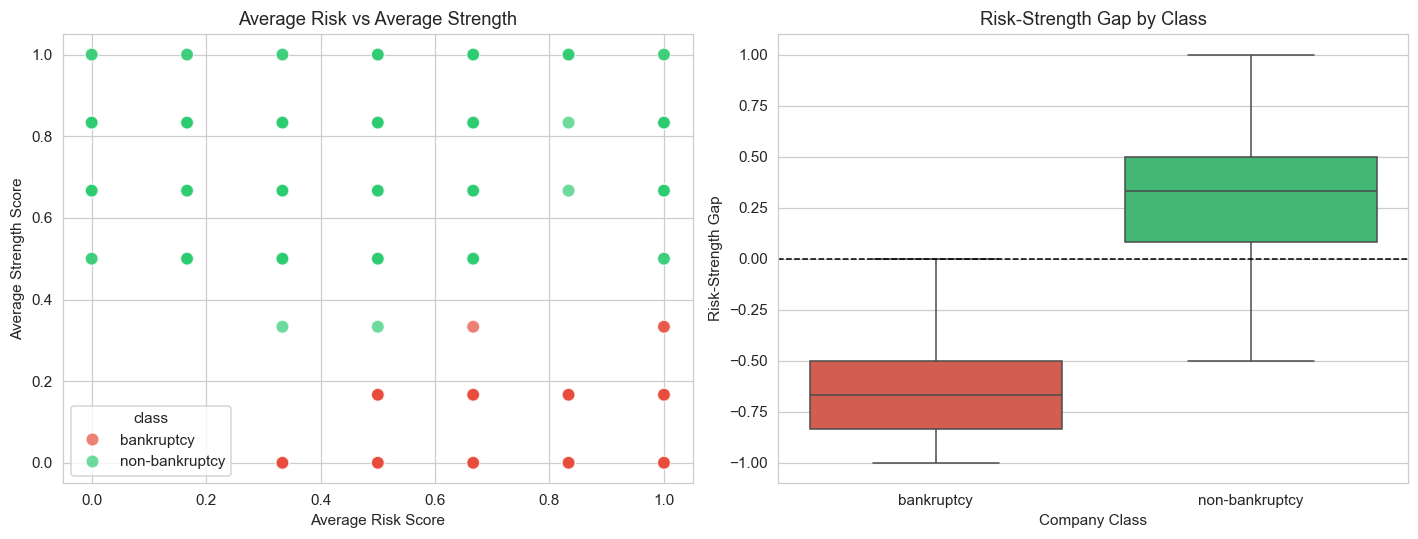

In [18]:
# Visualize the engineered features

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter Plot: Average Risk vs Average Strength
sns.scatterplot(
    data=df,
    x='avg_risk_score',
    y='avg_strength_score',
    hue='class',
    palette={
        'bankruptcy': '#e74c3c',
        'non-bankruptcy': '#2ecc71'
    },
    s=70,
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("Average Risk vs Average Strength")
axes[0].set_xlabel("Average Risk Score")
axes[0].set_ylabel("Average Strength Score")

# Box Plot: Risk-Strength Gap
sns.boxplot(
    data=df,
    x='class',
    y='risk_strength_gap',
    hue='class',
    palette={
        'bankruptcy': '#e74c3c',
        'non-bankruptcy': '#2ecc71'
    },
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Risk-Strength Gap by Class")
axes[1].set_xlabel("Company Class")
axes[1].set_ylabel("Risk-Strength Gap")
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


### Overall Observation:
The engineered features (avg_risk_score, avg_strength_score, and risk_strength_gap) capture the overall financial condition of a company more effectively than individual variables. The visualizations show that these features help differentiate between bankrupt and non-bankrupt companies, making them valuable inputs for the machine learning model.

### Prepare Features and Targe

In [21]:
original_features = [
    'industrial_risk',
    'management_risk',
    'financial_flexibility',
    'credibility',
    'competitiveness',
    'operating_risk'
]

X = df[original_features] # input column train the model  # <-- Only 6 features
y = df['target']#output column 
#Bankruptcy (1)
#Non-Bankruptcy (0)

## 5. Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    
)


In [24]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (200, 6)
X_test : (50, 6)
y_train: (200,)
y_test : (50,)


### Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Conclusion: 
Based on the EDA and feature engineering, the engineered features show a good distinction between bankrupt and non-bankrupt companies. Therefore, these features are included in the machine learning model to evaluate whether they improve prediction performance

### 6.Model Building

#### 1. Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
lr = LogisticRegression(random_state=42)

# Train Model
lr.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 1.0

Confusion Matrix:

[[29  0]
 [ 0 21]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



#### 2. Decision Tree

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
dt = DecisionTreeClassifier(random_state=42)

# Train Model
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.98

Confusion Matrix:

[[28  1]
 [ 0 21]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.95      1.00      0.98        21

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



#### 3. Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 1.0

Confusion Matrix:

[[29  0]
 [ 0 21]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



#### 4. K-Nearest Neighbors (KNN)

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
knn = KNeighborsClassifier(n_neighbors=5)

# Train Model
knn.fit(X_train_scaled, y_train)

# Prediction
y_pred_knn = knn.predict(X_test_scaled)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.98

Confusion Matrix:

[[28  1]
 [ 0 21]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.95      1.00      0.98        21

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



#### 5. Support Vector Machine (SVM)

In [38]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
svm = SVC(random_state=42)

# Train Model
svm.fit(X_train_scaled, y_train)

# Prediction
y_pred_svm = svm.predict(X_test_scaled)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy : 1.0

Confusion Matrix:

[[29  0]
 [ 0 21]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



#### 6. Naive Bayes

In [40]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
nb = GaussianNB()

# Train Model
nb.fit(X_train, y_train)

# Prediction
y_pred_nb = nb.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy : 0.98

Confusion Matrix:

[[29  0]
 [ 1 20]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.95      0.98        21

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



### Comparison Table

In [42]:
# Create an empty list
model_results = []

# Function to store model performance
def evaluate_model(model_name, y_true, y_pred):
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    })

# Add results of each model
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("SVM", y_test, y_pred_svm)
evaluate_model("Naive Bayes", y_test, y_pred_nb)

# Create DataFrame
comparison_df = pd.DataFrame(model_results)

# Convert to percentage
comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:] * 100

# Round values
comparison_df = comparison_df.round(2)

# Display table
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,100.0,100.00,100.00,100.00
1,Decision Tree,98.0,95.45,100.00,97.67
2,Random Forest,100.0,100.00,100.00,100.00
3,KNN,98.0,95.45,100.00,97.67
4,SVM,100.0,100.00,100.00,100.00
5,Naive Bayes,98.0,100.00,95.24,97.56


#### Visualize Model Comparison

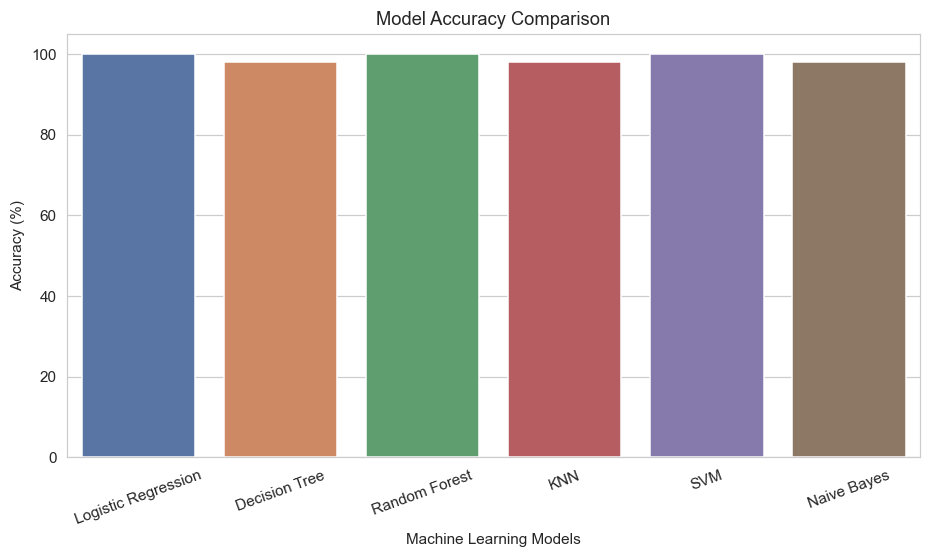

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="deep",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=20)

plt.show()

### display all the best models (Test Accuracy)

In [46]:
best_models = comparison_df[
    comparison_df["Accuracy"] == comparison_df["Accuracy"].max()
]

print(best_models)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     100.0      100.0   100.0     100.0
2        Random Forest     100.0      100.0   100.0     100.0
4                  SVM     100.0      100.0   100.0     100.0


### Cross-Validation for Logistic Regression

A single train-test split can give optimistic or pessimistic results depending on how the data is divided. Cross-validation evaluates the model on multiple splits, providing a more reliable estimate of performance.

In [49]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42))
])

# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Cross Validation Accuracy: {:.2f}%".format(cv_scores.mean() * 100))
print("Standard Deviation: {:.2f}".format(cv_scores.std()))

Cross Validation Scores:
[1.   1.   1.   0.98 1.  ]

Average Cross Validation Accuracy: 99.60%
Standard Deviation: 0.01


### Random Forest Cross-Validation

In [51]:
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline
rf_pipeline = Pipeline([
    ('random_forest', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Cross Validation Accuracy: {:.2f}%".format(cv_scores.mean() * 100))
print("Standard Deviation: {:.2f}".format(cv_scores.std()))

Cross Validation Scores:
[1.   1.   1.   0.98 1.  ]

Average Cross Validation Accuracy: 99.60%
Standard Deviation: 0.01


### SVM Cross-Validation

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Create a pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        random_state=42
    ))
])

# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Cross Validation Accuracy: {:.2f}%".format(cv_scores.mean() * 100))
print("Standard Deviation: {:.2f}".format(cv_scores.std()))

Cross Validation Scores:
[1.   1.   1.   0.98 1.  ]

Average Cross Validation Accuracy: 99.60%
Standard Deviation: 0.01


### Overfitting & Underfitting Check

In [55]:
from sklearn.metrics import accuracy_score

# Training Accuracy
train_pred = lr.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_pred)

# Testing Accuracy
test_pred = lr.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy :", round(train_accuracy * 100, 2), "%")
print("Testing Accuracy  :", round(test_accuracy * 100, 2), "%")

Training Accuracy : 99.5 %
Testing Accuracy  : 100.0 %


The difference between training and testing accuracy is only 0.5%, indicating that the model generalizes well and does not exhibit significant overfitting or underfitting.

#### Comparison Table for Test Accuracy and cross validation Accuracy

In [58]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Test Accuracy (%)": [100, 100, 100],
    "Cross Validation Accuracy (%)": [99.60, 99.60, 99.60]
})

comparison

,Model,Test Accuracy (%),Cross Validation Accuracy (%)
0,Logistic Regression,100,99.6
1,Random Forest,100,99.6
2,SVM,100,99.6


### The best model(Linear Regression)

In [60]:
best_models = comparison[
    comparison["Cross Validation Accuracy (%)"] ==
    comparison["Cross Validation Accuracy (%)"].max()
]

print("Best Performing Models:")
print(best_models)

Best Performing Models:
                 Model  Test Accuracy (%)  Cross Validation Accuracy (%)
0  Logistic Regression                100                           99.6
1        Random Forest                100                           99.6
2                  SVM                100                           99.6


compared six machine learning algorithms. Logistic Regression, Random Forest, and SVM all achieved the same Test Accuracy (100%) and Cross Validation Accuracy (99.6%). Since all three models performed equally well, I selected Logistic Regression because it is simpler, computationally efficient, easier to interpret, and easier to deploy. According to the principle of choosing the simplest model with equal performance, Logistic Regression was the most suitable choice."

### Feature Importance (Logistic regression)

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coef["Absolute"] = coef["Coefficient"].abs()
coef = coef.sort_values("Absolute", ascending=False)

coef

,Feature,Coefficient,Absolute
4,competitiveness,-2.761019,2.761019
3,credibility,-1.427631,1.427631
2,financial_flexibility,-1.318951,1.318951
1,management_risk,0.514647,0.514647
0,industrial_risk,0.367073,0.367073
5,operating_risk,0.006687,0.006687


Positive coefficient (+) → increases the probability of bankruptcy.

Negative coefficient (−) → decreases the probability of bankruptcy.

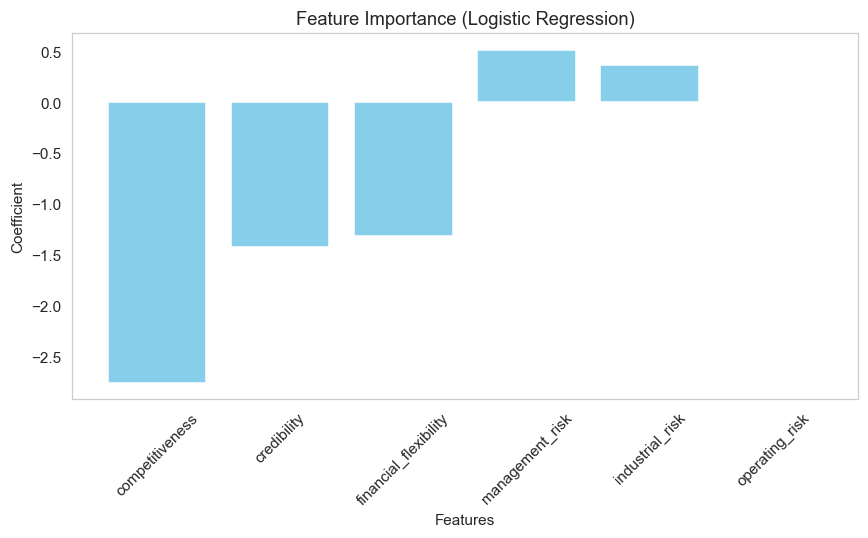

In [65]:
plt.figure(figsize=(8,5))

plt.bar(coef["Feature"], coef["Coefficient"], color="skyblue")

plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Importance (Logistic Regression)")

plt.xticks(rotation=45)
plt.grid(False)

plt.tight_layout()
plt.show()

In [66]:
print(coef)

                 Feature  Coefficient  Absolute
4        competitiveness    -2.761019  2.761019
3            credibility    -1.427631  1.427631
2  financial_flexibility    -1.318951  1.318951
1        management_risk     0.514647  0.514647
0        industrial_risk     0.367073  0.367073
5         operating_risk     0.006687  0.006687


The graph shows the coefficients of each feature used by the Logistic Regression model. Features with positive coefficients increase the chances of a company being classified as bankrupt, while features with negative coefficients decrease the chances of bankruptcy. The larger the absolute value of a coefficient, the greater its influence on the model's prediction. This helps identify which risk and financial factors have the strongest impact on bankruptcy prediction.

ROC-AUC Score: 1.0


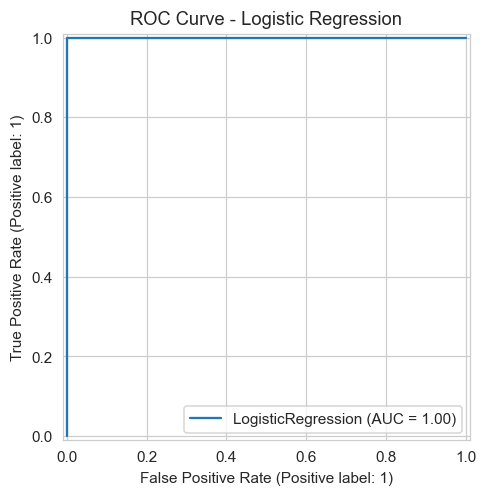

In [68]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", round(roc_auc, 4))

# Plot ROC Curve
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

plt.title("ROC Curve - Logistic Regression")
plt.show()

#### Observation:
The ROC curve lies close to the top-left corner of the graph, and the Logistic Regression model achieved an AUC score of 1.00. This indicates perfect discrimination between bankrupt and non-bankrupt companies on the test dataset. The model correctly identifies positive cases while producing no false positives, demonstrating excellent classification performance.

### Deployement

In [71]:
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(lr, f)


with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(" Logistic Regression model and scaler saved successfully.")

 Logistic Regression model and scaler saved successfully.
